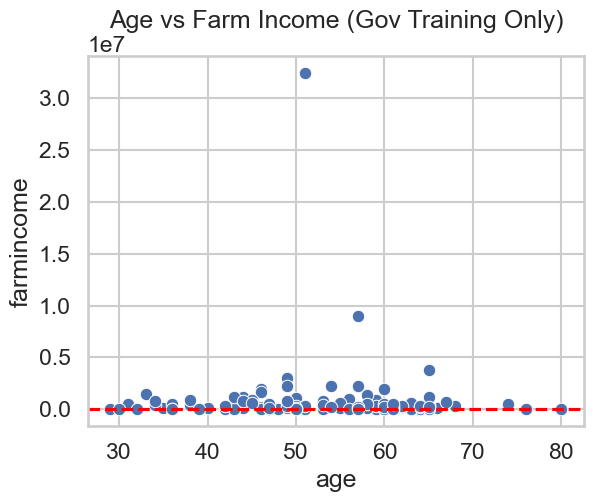

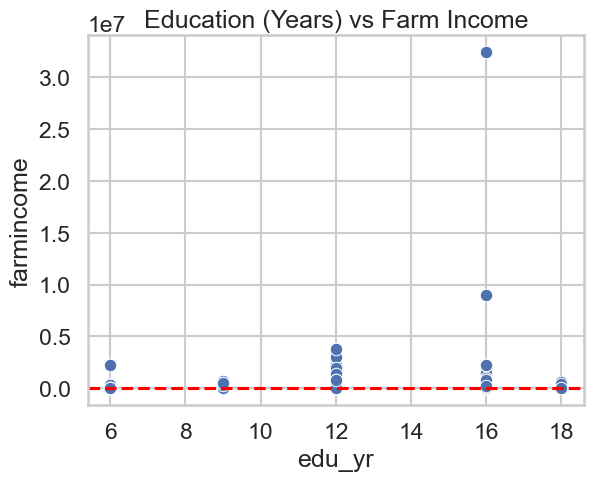

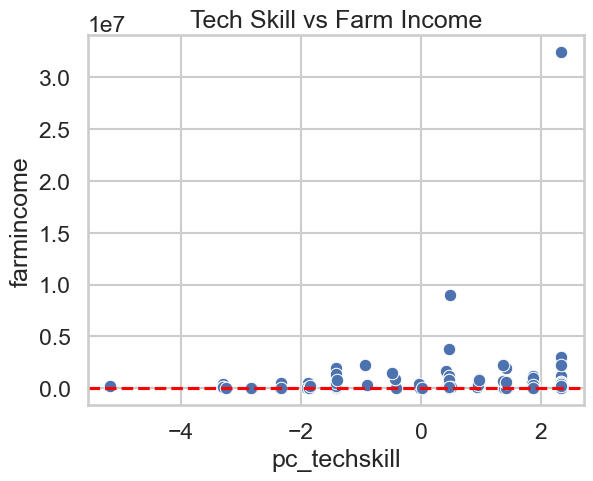

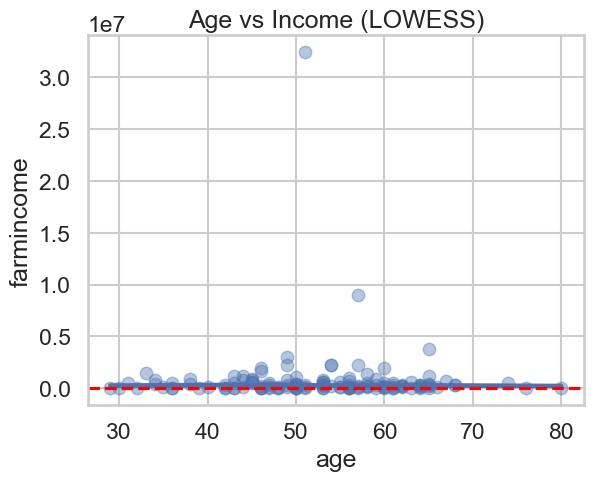

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("GovTrainingImpact_Croo66-Y=1-23Feb2026final.csv")

main_df = df.copy()  # เก็บสำรองไว้ก่อน

# ✅ filter: เข้าร่วม training
df = df[df["gov_train"] == 1]

# ✅ clean (สำคัญ)
df = df[["age", "edu_yr", "pc_techskill", "agri_tech_adapt", "farmincome"]].dropna()

# =========================
# 1) AGE vs FARM INCOME
# =========================
plt.figure()
sns.scatterplot(data=df, x="age", y="farmincome")

plt.axhline(0, linestyle="--", color="red")  # highlight negative income
plt.title("Age vs Farm Income (Gov Training Only)")
plt.show()


# =========================
# 2) EDUCATION vs FARM INCOME
# =========================
plt.figure()
sns.scatterplot(data=df, x="edu_yr", y="farmincome")

plt.axhline(0, linestyle="--", color="red")
plt.title("Education (Years) vs Farm Income")
plt.show()


# =========================
# 3) TECH SKILL vs FARM INCOME
# =========================
plt.figure()
sns.scatterplot(data=df, x="pc_techskill", y="farmincome")

plt.axhline(0, linestyle="--", color="red")
plt.title("Tech Skill vs Farm Income")
plt.show()


# =========================
# 4) OPTIONAL: smoother (pattern clearer)
# =========================
plt.figure()
sns.regplot(data=df, x="age", y="farmincome", lowess=True,
            scatter_kws={"alpha":0.4})
plt.axhline(0, linestyle="--", color="red")
plt.title("Age vs Income (LOWESS)")
plt.show()


=== AGE ===
              count       mean        std   min   25%   50%   75%   max
income_group                                                           
Negative       39.0  50.153846  10.815531  29.0  43.0  50.0  58.5  76.0
Low            91.0  53.582418   9.365499  31.0  47.0  54.0  60.5  80.0

=== EDUCATION ===
              count       mean       std  min   25%   50%   75%   max
income_group                                                         
Negative       39.0  11.461538  3.925934  6.0   6.0  12.0  16.0  16.0
Low            91.0  13.076923  3.344085  6.0  12.0  12.0  16.0  18.0

=== TECH USE ===
              count      mean       std  min  25%  50%  75%  max
income_group                                                    
Negative       39.0  0.923077  0.269953  0.0  1.0  1.0  1.0  1.0
Low            91.0  0.967033  0.179540  0.0  1.0  1.0  1.0  1.0

=== RISK ===
              count      mean       std  min  25%  50%  75%  max
income_group                               

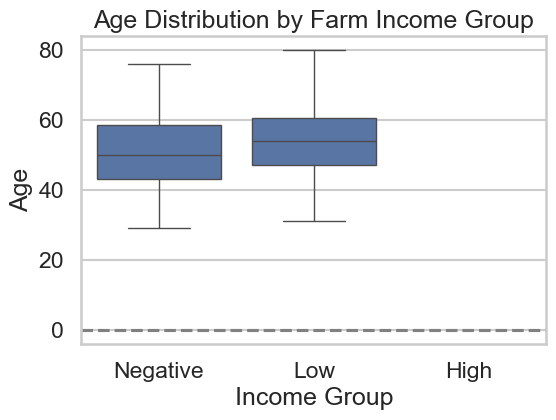

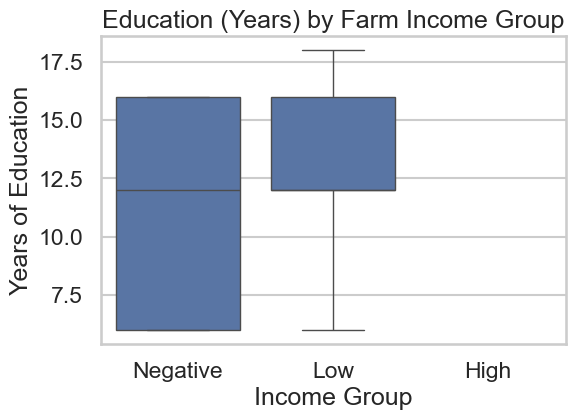

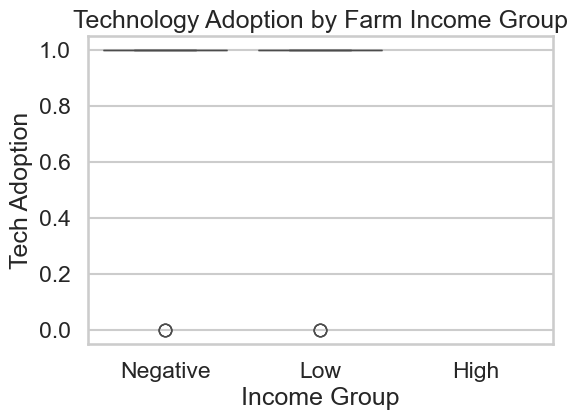

ValueError: Could not interpret value `overview_risk` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [19]:
# ==========================================
# 2) FILTER: GOV TRAINING ONLY
# ==========================================
df = main_df[main_df["gov_train"] == 1]

# ==========================================
# 3) SELECT VARIABLES
# ==========================================
# core variables for analysis
df = df[[
    "att",
    #"farmincome",     # income (main independent grouping variable)
    "age",            # outcome 1
    "edu_yr",         # outcome 2
    "agri_tech_adapt",# outcome 3 (technology use)
    "risk_quartile"   # outcome 4 (farm risk)
]].dropna()

# ==========================================
# 4) CREATE INCOME GROUP (KEY STEP)
# ==========================================
"""
แบ่งกลุ่มรายได้เป็น 3 กลุ่ม:
- Negative  = ขาดทุน
- Low       = กำไรต่ำ
- High      = กำไรสูง

→ ทำให้ "crosstab + visualization" meaningful
"""

df["income_group"] = pd.cut(
    # df["farmincome"],
    df["att"],
    bins=[-1e9, 0, 200000, 1e9],
    labels=["Negative", "Low", "High"]
)

# ==========================================
# 5) CROSSTAB (TABLE)
# ==========================================
"""
ใช้ดู distribution แบบตาราง
→ เหมาะกับ report / appendix
"""

crosstab_age = df.groupby("income_group")["age"].describe()
crosstab_edu = df.groupby("income_group")["edu_yr"].describe()
crosstab_tech = df.groupby("income_group")["agri_tech_adapt"].describe()
crosstab_risk = df.groupby("income_group")["risk_quartile"].describe()

print("\n=== AGE ===")
print(crosstab_age)

print("\n=== EDUCATION ===")
print(crosstab_edu)

print("\n=== TECH USE ===")
print(crosstab_tech)

print("\n=== RISK ===")
print(crosstab_risk)


# ==========================================
# 6) VISUALIZATION (CORE FIGURES)
# ==========================================

# -------- 6.1 AGE ----------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="income_group", y="age")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Age Distribution by Farm Income Group")
plt.xlabel("Income Group")
plt.ylabel("Age")
plt.show()


# -------- 6.2 EDUCATION ----------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="income_group", y="edu_yr")
plt.title("Education (Years) by Farm Income Group")
plt.xlabel("Income Group")
plt.ylabel("Years of Education")
plt.show()


# -------- 6.3 TECHNOLOGY USE ----------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="income_group", y="agri_tech_adapt")
plt.title("Technology Adoption by Farm Income Group")
plt.xlabel("Income Group")
plt.ylabel("Tech Adoption")
plt.show()


# -------- 6.4 RISK ----------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="income_group", y="overview_risk")
plt.title("Farm Risk by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Risk Level")
plt.show()


# ==========================================
# 7) ROBUST FIGURE (FOR PAPER)
# ==========================================
"""
barplot + confidence interval
→ ใช้เป็น main figure ใน paper ได้เลย
"""

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="income_group", y="agri_tech_adapt", errorbar="ci")
plt.title("Average Technology Adoption by Income Group (CI)")
plt.show()

# ==========================================
# 8) OPTIONAL: YOUNG vs OLD TEST
# ==========================================
"""
เช็ค hypothesis:
"young farmers → negative income"
"""

df["young"] = df["age"] < 40

print("\n=== Mean Income by Young vs Old ===")
print(df.groupby("young")["att"].mean())



/var/folders/7l/zffgp8nd1wbb6qkk7lg__0_c0000gn/T/ipykernel_7712/4268527854.py:75: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/7l/zffgp8nd1wbb6qkk7lg__0_c0000gn/T/ipykernel_7712/4268527854.py:75: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/7l/zffgp8nd1wbb6qkk7lg__0_c0000gn/T/ipykernel_7712/4268527854.py:75: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/7l/zffgp8nd1wbb6qkk7lg__0_c0000gn/T/ipykernel_7712/4268527854.py:75: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


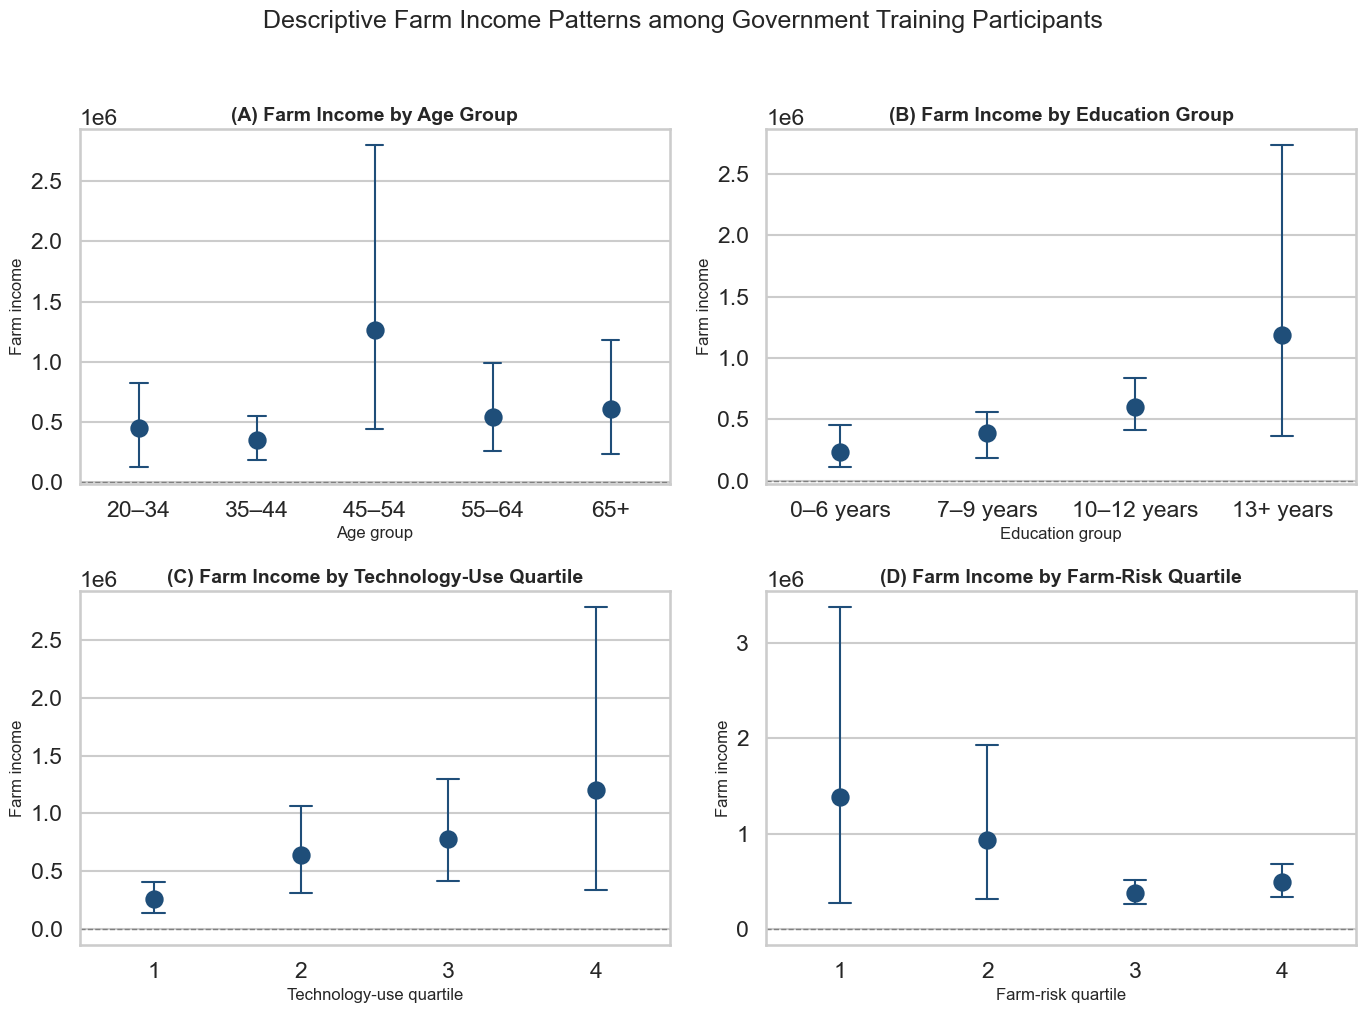


=== Mean farm income by age group ===
                count          mean    median           std
age_group_desc                                             
20–34               7  4.513571e+05  414000.0  5.306543e+05
35–44              18  3.552739e+05  117500.0  4.171733e+05
45–54              46  1.265140e+06  327000.0  4.747149e+06
55–64              46  5.435385e+05  194384.0  1.360163e+06
65+                13  6.128910e+05  320000.0  1.007409e+06

=== Mean farm income by education group ===
                count          mean    median           std
edu_group_desc                                             
0–6 years          21  2.374979e+05  129000.0  4.643124e+05
7–9 years           5  3.897554e+05  480000.0  2.524632e+05
10–12 years        51  6.005602e+05  360000.0  7.693172e+05
13+ years          53  1.191631e+06  252000.0  4.557778e+06

=== Mean farm income by technology quartile ===
               count          mean    median           std
tech_quartile               

In [20]:
# ============================================
# Descriptive figures for paper-style presentation
# Dataset: GovTrainingImpact_Croo66-Y=1-23Feb2026final.csv
# Purpose:
#   Use REAL farm income (not regression prediction)
#   to create clean descriptive figures before presenting
#   marginal effects from regression model.
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1) Load data
# -------------------------------
FILE = "GovTrainingImpact_Croo66-Y=1-23Feb2026final.csv"
df = pd.read_csv(FILE)

# -------------------------------
# 2) Keep only participants in government training
# -------------------------------
df = df[df["gov_train"] == 1].copy()

# -------------------------------
# 3) Create grouped variables
# -------------------------------
# Age group (similar spirit to the figure in the attached PDF)
df["age_group_desc"] = pd.cut(
    df["age"],
    bins=[20, 35, 45, 55, 65, 200],
    labels=["20–34", "35–44", "45–54", "55–64", "65+"],
    right=False
)

# Education group from years of education
# 0–6, 7–9, 10–12, 13+
df["edu_group_desc"] = pd.cut(
    df["edu_yr"],
    bins=[0, 7, 10, 13, 100],
    labels=["0–6 years", "7–9 years", "10–12 years", "13+ years"],
    right=False
)

# -------------------------------
# 4) Keep only needed columns and drop missing
# -------------------------------
use_cols = [
    "farmincome",
    "age_group_desc",
    "edu_group_desc",
    "tech_quartile",
    "risk_quartile"
]
plot_df = df[use_cols].dropna().copy()

# Optional: make quartiles categorical for ordered plotting
plot_df["tech_quartile"] = plot_df["tech_quartile"].astype("category")
plot_df["risk_quartile"] = plot_df["risk_quartile"].astype("category")

# -------------------------------
# 5) Plot settings
# -------------------------------
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Descriptive Farm Income Patterns among Government Training Participants",
    fontsize=18,
    y=1.02
)

# A helper function to make consistent plots
def income_pointplot(data, x, ax, title, xlabel):
    sns.pointplot(
        data=data,
        x=x,
        y="farmincome",
        errorbar=("ci", 95),
        join=False,
        dodge=False,
        capsize=0.15,
        err_kws={"linewidth": 1.5},
        markers="o",
        color="#1f4e79",
        ax=ax
    )
    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Farm income", fontsize=12)

# -------------------------------
# 6) Four descriptive figures
# -------------------------------
income_pointplot(
    plot_df,
    x="age_group_desc",
    ax=axes[0, 0],
    title="(A) Farm Income by Age Group",
    xlabel="Age group"
)

income_pointplot(
    plot_df,
    x="edu_group_desc",
    ax=axes[0, 1],
    title="(B) Farm Income by Education Group",
    xlabel="Education group"
)

income_pointplot(
    plot_df,
    x="tech_quartile",
    ax=axes[1, 0],
    title="(C) Farm Income by Technology-Use Quartile",
    xlabel="Technology-use quartile"
)

income_pointplot(
    plot_df,
    x="risk_quartile",
    ax=axes[1, 1],
    title="(D) Farm Income by Farm-Risk Quartile",
    xlabel="Farm-risk quartile"
)

plt.tight_layout()

# -------------------------------
# 7) Save figure
# -------------------------------
plt.savefig("descriptive_farm_income_panels.png", dpi=300, bbox_inches="tight")
plt.savefig("descriptive_farm_income_panels.pdf", bbox_inches="tight")
plt.show()

# -------------------------------
# 8) Print summary tables (optional but useful for writing)
# -------------------------------
print("\n=== Mean farm income by age group ===")
print(plot_df.groupby("age_group_desc", observed=False)["farmincome"].agg(["count", "mean", "median", "std"]))

print("\n=== Mean farm income by education group ===")
print(plot_df.groupby("edu_group_desc", observed=False)["farmincome"].agg(["count", "mean", "median", "std"]))

print("\n=== Mean farm income by technology quartile ===")
print(plot_df.groupby("tech_quartile", observed=False)["farmincome"].agg(["count", "mean", "median", "std"]))

print("\n=== Mean farm income by risk quartile ===")
print(plot_df.groupby("risk_quartile", observed=False)["farmincome"].agg(["count", "mean", "median", "std"]))


In [ ]:
# ============================================
# EXPORT SUMMARY TABLES TO CSV
# ============================================

# function ช่วยลดซ้ำ
def export_summary(df, group_var, filename):
    summary = (
        df.groupby(group_var, observed=False)["farmincome"]
        .agg(
            N="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            p25=lambda x: x.quantile(0.25),
            p75=lambda x: x.quantile(0.75),
            max="max"
        )
        .reset_index()
    )
    
    summary.to_csv(filename, index=False)
    print(f"Saved: {filename}")
    return summary


# ============================================
# EXPORT EACH TABLE
# ============================================

age_table = export_summary(plot_df, "age_group_desc",
                          "table_age_income.csv")

edu_table = export_summary(plot_df, "edu_group_desc",
                          "table_education_income.csv")

tech_table = export_summary(plot_df, "tech_quartile",
                           "table_tech_income.csv")

risk_table = export_summary(plot_df, "risk_quartile",
                           "table_risk_income.csv")


# ============================================
# OPTIONAL: ALL-IN-ONE FILE
# ============================================

age_table["variable"] = "Age"
edu_table["variable"] = "Education"
tech_table["variable"] = "Technology"
risk_table["variable"] = "Risk"

combined = pd.concat([
    age_table.rename(columns={"age_group_desc": "group"}),
    edu_table.rename(columns={"edu_group_desc": "group"}),
    tech_table.rename(columns={"tech_quartile": "group"}),
    risk_table.rename(columns={"risk_quartile": "group"})
], ignore_index=True)

combined.to_csv("table_all_income_summary.csv", index=False)

print("Saved: table_all_income_summary.csv")